In [2]:
### Build A Basic Chatbot

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from typing import Annotated

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3-32b")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001C9D62304D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001C9D765F380>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [8]:
def chatbot(state:State):
    return {"messages":llm.invoke(state["messages"])}

In [9]:
graph_builder=StateGraph(State) 
graph_builder.add_node("chatbot",chatbot)
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)
graph=graph_builder.compile()

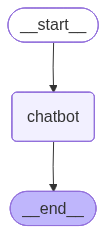

In [9]:
from IPython.display import Image,display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [13]:
response=graph.invoke({"messages":"hii"})
response["messages"][-1].content

'<think>\nOkay, the user said "hii". That\'s a casual greeting. I should respond in a friendly and welcoming way. Maybe start with a greeting of my own, like "Hello! 😊". Then ask how I can assist them today. Keep it open-ended so they feel comfortable to ask for help. Make sure the emoji adds a friendly tone without being over the top. Check for any typos and ensure the response is concise.\n</think>\n\nHello! 😊 How can I assist you today?'